In [1]:
library(conText)
library(quanteda)
library(dplyr)
library(ggplot2)
library(stringr)

conText v3.0.1 successfully loaded. Note this version of the package comes with significant changes to the conText() function.
                        See Quick Start Guide for help getting started and instructions for accessing older versions of the package:
 https://github.com/prodriguezsosa/conText/blob/master/vignettes/quickstart.md

Package version: 4.3.1
Unicode version: 15.0
ICU version: 73.2

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
anchor_dems <- readRDS("ALC_dems/anchors.rds")

In [4]:
dict_terms <- readRDS("Results_Files/dict_terms_final_0510.rds")

## Subset function

In [115]:
subset_by_source <- function(term_data, source, year, reclassify_editorials = FALSE) {
  
  ## Limit to editorial or not 
  if (reclassify_editorials) {
    term_data$docvars$Type[str_detect(term_data$docvars$Type, 
                                      "Commentary|Editorial|Review")] <- "Editorial"
    idx <- which(term_data$docvars$Source == source &
                 term_data$docvars$Year == year & 
                 term_data$docvars$Type == "Editorial")
  } else {
      idx <- which(term_data$docvars$Source == source  &
               term_data$docvars$Year == year)
      }
    
  list(
    matrix = term_data$matrix[idx, , drop = FALSE],
    docvars = term_data$docvars[idx, ]
  )
}

### Editorials Only

In [127]:
cosine_calculate <- function(topic, source){
    
    ## Create empty list to store dataframes
    results <- list()
    
    ## Read DEM files
    file_name <- paste0("ALC_dems/topic_", topic, ".rds")
    topic_dem <- readRDS(file_name)
    
    for (y in 1980:2024){
        ## Create empty vectors for later use
        cor_lib <- c()
        cor_con <- c()
        cor_dem <- c()
        cor_rep <- c()
        
        ## Subset by Source, Year, and Type
        topic_list <- lapply(topic_dem, subset_by_source, source = source, year = y, reclassify_editorials = TRUE)
        anchor_list <- lapply(anchor_dems, subset_by_source, source = source, year = y, reclassify_editorials = TRUE)

        ## Cosine Similarity
        for(i in 1:length(topic_list)){
            if(length(topic_list[[i]]$matrix)==0) {
                cor_lib[i] <- NA
                cor_con[i] <- NA
                cor_dem[i] <- NA
                cor_rep[i] <- NA
            } else{
                cor_lib[i] <- lsa::cosine(colMeans(anchor_list$liberal$matrix), colMeans(topic_list[[i]]$matrix))
                cor_con[i] <- lsa::cosine(colMeans(anchor_list$conservative$matrix), colMeans(topic_list[[i]]$matrix))
                cor_dem[i] <- lsa::cosine(colMeans(anchor_list$democrat$matrix), colMeans(topic_list[[i]]$matrix))
                cor_rep[i] <- lsa::cosine(colMeans(anchor_list$republican$matrix), colMeans(topic_list[[i]]$matrix))
            }
        }
        
        results[[length(results) + 1]] <- data.frame(
            term = names(topic_list),
            year = as.integer(y),
            cos_lib = cor_lib,
            cos_con = cor_con,
            cos_dem = cor_dem,
            cos_rep = cor_rep
        )
    }
    
    results_df <- do.call(rbind, results)
    return(results_df)

}

In [128]:
test_df <- cosine_calculate(10, "New York Times")

head(test_df)

,term,year,cos_lib,cos_con,cos_dem,cos_rep
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,diversity,1980,0.3351214,0.3167736,0.1365701,0.1484802
2,hispanic,1980,0.3303603,0.2242814,0.2669017,0.2422293
3,discrimination,1980,0.5365258,0.4769586,0.3820487,0.4159978
4,minorities,1980,0.5115493,0.5018141,0.3901223,0.4747907
5,ethnic,1980,0.3730772,0.3983153,0.2073652,0.3465665
6,affirmative-action,1980,0.3571085,0.3173481,0.2113728,0.2437307


In [ ]:
nyt_cos_edit <- lapply(unique(dict_terms$topic), cosine_calculate, source = "New York Times")

nyt_cos_edit_df <-  do.call(rbind, nyt_cos_edit)

saveRDS(nyt_cos_edit_df, "nyt_cos_edit_df.rds")

In [ ]:
wp_cos_edit <- lapply(unique(dict_terms$topic), cosine_calculate, source = "The Washington Post")

wp_cos_edit_df <-  do.call(rbind, wp_cos_edit)

saveRDS(wp_cos_edit_df, "wp_cos_edit_df.rds")

In [ ]:
wsj_cos_edit <- lapply(unique(dict_terms$topic), cosine_calculate, source = "Wall Street Journal")

In [ ]:
wsj_cos_edit_df <-  do.call(rbind, wsj_cos_edit)

saveRDS(wsj_cos_edit_df, "wsj_cos_edit_df.rds")

In [139]:
head(nyt_cos_edit_df)

,term,year,cos_lib,cos_con,cos_dem,cos_rep
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,business,1980,0.6526280,0.6685349,0.5627432,0.57771393
2,entrepreneurs,1980,0.3246797,0.2781101,0.2585168,0.23716500
3,small-businesses,1980,0.1317049,0.1747117,0.1111915,0.09586828
4,entrepreneurship,1980,NA,NA,NA,NA
5,small-business,1980,NA,NA,NA,NA
6,entrepreneurial,1980,0.2773400,0.2214940,0.1132532,0.17207725


### All Articles by Outlet

In [137]:
cosine_calculate <- function(topic, source){
    
    ## Create empty list to store dataframes
    results <- list()
    
    ## Read DEM files
    file_name <- paste0("ALC_dems/topic_", topic, ".rds")
    topic_dem <- readRDS(file_name)
    
    for (y in 1980:2024){
        ## Create empty vectors for later use
        cor_lib <- c()
        cor_con <- c()
        cor_dem <- c()
        cor_rep <- c()
        
        ## Subset by Source, Year, and Type
        topic_list <- lapply(topic_dem, subset_by_source, source = source, year = y, reclassify_editorials = FALSE)
        anchor_list <- lapply(anchor_dems, subset_by_source, source = source, year = y, reclassify_editorials = FALSE)

        ## Cosine Similarity
        for(i in 1:length(topic_list)){
            if(length(topic_list[[i]]$matrix)==0) {
                cor_lib[i] <- NA
                cor_con[i] <- NA
                cor_dem[i] <- NA
                cor_rep[i] <- NA
            } else{
                cor_lib[i] <- lsa::cosine(colMeans(anchor_list$liberal$matrix), colMeans(topic_list[[i]]$matrix))
                cor_con[i] <- lsa::cosine(colMeans(anchor_list$conservative$matrix), colMeans(topic_list[[i]]$matrix))
                cor_dem[i] <- lsa::cosine(colMeans(anchor_list$democrat$matrix), colMeans(topic_list[[i]]$matrix))
                cor_rep[i] <- lsa::cosine(colMeans(anchor_list$republican$matrix), colMeans(topic_list[[i]]$matrix))
            }
        }
        
        results[[length(results) + 1]] <- data.frame(
            term = names(topic_list),
            year = as.integer(y),
            cos_lib = cor_lib,
            cos_con = cor_con,
            cos_dem = cor_dem,
            cos_rep = cor_rep
        )
    }
    
    results_df <- do.call(rbind, results)
    return(results_df)

}

In [138]:
nyt_cos <- lapply(unique(dict_terms$topic), cosine_calculate, source = "New York Times")

nyt_cos_df <-  do.call(rbind, nyt_cos)

saveRDS(nyt_cos_df, "nyt_cos_df.rds")

In [140]:
head(nyt_cos_df)

,term,year,cos_lib,cos_con,cos_dem,cos_rep
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,business,1980,0.5235480,0.5557871,0.4716460,0.5113363
2,entrepreneurs,1980,0.3903411,0.4115801,0.4093058,0.3787597
3,small-businesses,1980,0.3060698,0.2880211,0.2203592,0.2552422
4,entrepreneurship,1980,0.2506410,0.2772001,0.1109134,0.1655765
5,small-business,1980,0.3144399,0.3343057,0.2893989,0.2800041
6,entrepreneurial,1980,0.2595330,0.2600953,0.2428389,0.2422623


In [141]:
wp_cos <- lapply(unique(dict_terms$topic), cosine_calculate, source = "The Washington Post")

wp_cos_df <-  do.call(rbind, wp_cos)

saveRDS(wp_cos_df, "wp_cos_df.rds")

In [142]:
wsj_cos <- lapply(unique(dict_terms$topic), cosine_calculate, source = "Wall Street Journal")

wsj_cos_df <-  do.call(rbind, wsj_cos)

saveRDS(wsj_cos_df, "wsj_cos_df.rds")

## Combine

In [2]:
nyt_cos_df <- readRDS("nyt_cos_df.rds")
wp_cos_df <- readRDS("wp_cos_df.rds")
wsj_cos_df <- readRDS("wsj_cos_df.rds")

In [5]:
nyt_cos_df$Source = "New York Times"
wp_cos_df$Source = "The Washington Post"
wsj_cos_df$Source = "Wall Street Journal"

all_df <- rbind(nyt_cos_df, wp_cos_df, wsj_cos_df) %>%
            left_join(dict_terms, by = "term") %>%
            filter(!is.na(label))

head(all_df)

,term,year,cos_lib,cos_con,cos_dem,cos_rep,Source,topic,beta,ratio,label,decision
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>
1,business,1980,0.5235480,0.5557871,0.4716460,0.5113363,New York Times,1,0.150807247,44.60554,Business,keep
2,entrepreneurs,1980,0.3903411,0.4115801,0.4093058,0.3787597,New York Times,1,0.004627995,160.73382,Business,keep
3,small-businesses,1980,0.3060698,0.2880211,0.2203592,0.2552422,New York Times,1,0.004054061,67.26768,Business,keep
4,entrepreneurship,1980,0.2506410,0.2772001,0.1109134,0.1655765,New York Times,1,0.001514838,83.76290,Business,keep
5,small-business,1980,0.3144399,0.3343057,0.2893989,0.2800041,New York Times,1,0.001480054,48.64814,Business,keep
6,entrepreneurial,1980,0.2595330,0.2600953,0.2428389,0.2422623,New York Times,1,0.001410486,37.02148,Business,keep


In [6]:
all_df_cat <- 
    all_df %>%
    mutate(Category = case_when(
      label %in% c("Abortion", "Gender", "LGBTQ", "Marriage", "Parenting") ~ "Gender and Family",
      label %in% c("Catholicism", "Religion") ~ "Religion",
      label %in% c("Minority", "Native_American", "Racial", "Confederate", "Immigration") ~ "Race and Immigration",
      label %in% c("Campaigns & Donors", "Protest", "PublicOpinion", "Senate", "Elections") ~ "Politics",
      label %in% c("CriminalJustice", "Investigation", "Criminal", "Burglary", 
                   "Homicide", "Police") ~ "Crime and Policing",
      label %in% c("Constitution_Law", "Judicial", "Lawsuit", "SupremeCourt") ~ "Legal Institution",
      label %in% c("Higher_Education", "Education") ~ "Education",
      label %in% c("Science") ~ "Science",
      label %in% c("Gun_Control") ~ "Gun",
      label %in% c("Bankruptcy", "Banks", "Commodity_Market", "Corporate", "CorporateFinance",
                   "Earnings", "ExecutiveCompensation", "Financial", "Investing", "Money_Markets",
                   "Retail", "Securities",
                   "Stock_market", "Foreign_exchange") ~ "Financial Market",
      label %in% c("Welfare & Poverty", "Taxation", "Economics", "Agriculture", "Business",
                   "Economy", "Fiscal", "Labor", "Workers", "MonetaryPolicy", "Trade") ~ "Economic Issues",
      label %in% c("Housing", "Urban_development", "Mortgage", "Architecture") ~ "Housing",
      label %in% c("China", "Espionage", "Latin_America", "Middle_East",
                   "MiddleEastConflict", "Military", "NuclearArms", "Terrorism", "Russia & Ukraine") ~ "Foreign Affairs",
      label %in% c("ClimateChange", "Disaster", "Air Pollution",
                   "Weather", "Wildfires") ~ "Environment",
      label %in% c("Healthcare", "Hospital", "MentalHealth", "Nutrition", "Pharmaceuticals",
                   "Substance Abuse", "Vaccine", "Disease") ~ "Health",
      label %in% c("Art",  "Broadway",  "Classical_Music", 
                      "Museum", "Fashion", 
                      "Literature", "Movie", "Music") ~ "Creative Arts",
      label %in% c("Festival", "TravelIndustry", "Horticulture", "Nature", "Gaming") ~ "Leisure",
      label %in% c("Culinary", "Dining",  "Wine", "Beverage") ~ "Food & Drinks",
      label %in% c("Journalism", "Radio", "Television", "TV_Entertainment") ~ "Media",
      label %in% c("AmericanFootball", "Baseball", "NBA", "NFL", "Boxing",
                   "CollegeSports", "Golf", "NHL", "Soccer",  "Tennis") ~ "Sports",
      label %in% c("Electricity", "Energy", "Postal_service",  "Telecommunications", "Water") ~ "Infrastructure",
      label %in% c("Maritime",  "Mass_Transit", "Airline", "Automotive",
                    "Railroad", "Traffic", "Transportation") ~ "Transportation",
      label %in% c("Animal", "Marine_Biology",  "Wildlife") ~ "Animals",
      label %in% c("Home", "Household", "Cooking") ~ "Home",
      label == "Space" ~ "Outer Space",
      TRUE ~ "Other"))

head(all_df_cat)

,term,year,cos_lib,cos_con,cos_dem,cos_rep,Source,topic,beta,ratio,label,decision,Category
,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,business,1980,0.5235480,0.5557871,0.4716460,0.5113363,New York Times,1,0.150807247,44.60554,Business,keep,Economic Issues
2,entrepreneurs,1980,0.3903411,0.4115801,0.4093058,0.3787597,New York Times,1,0.004627995,160.73382,Business,keep,Economic Issues
3,small-businesses,1980,0.3060698,0.2880211,0.2203592,0.2552422,New York Times,1,0.004054061,67.26768,Business,keep,Economic Issues
4,entrepreneurship,1980,0.2506410,0.2772001,0.1109134,0.1655765,New York Times,1,0.001514838,83.76290,Business,keep,Economic Issues
5,small-business,1980,0.3144399,0.3343057,0.2893989,0.2800041,New York Times,1,0.001480054,48.64814,Business,keep,Economic Issues
6,entrepreneurial,1980,0.2595330,0.2600953,0.2428389,0.2422623,New York Times,1,0.001410486,37.02148,Business,keep,Economic Issues


In [7]:
# Politicization score
all_df_cat <-
    all_df_cat %>%
    mutate(pol_score_ideo = (cos_lib + cos_con)/2,
           pol_score_party = (cos_dem + cos_rep)/2)

In [8]:
# Combine term frequency
freq_by_year_source <- readRDS("freq_by_year_source.rds")
freq_by_year_source <- rename(freq_by_year_source, "year" = Year)
freq_by_year_source$year = as.numeric(freq_by_year_source$year)

head(freq_by_year_source)

doc_id,term,frequency,year,Source
<chr>,<chr>,<dbl>,<dbl>,<chr>
1980.New York Times,cooking,263,1980,New York Times
1980.New York Times,photography,221,1980,New York Times
1980.New York Times,laboratory,177,1980,New York Times
1980.New York Times,museum,793,1980,New York Times
1980.New York Times,solar,185,1980,New York Times
1980.New York Times,cents,1039,1980,New York Times


In [9]:
all_df_cat <-
    all_df_cat %>% 
    left_join(freq_by_year_source, by= c("term", "year", "Source"))

In [9]:
topic_words <-
  all_df_cat %>%
  distinct(term, label, Category)

topic_words <-
    topic_words %>%
    group_by(label, Category) %>%
    summarise(all_terms = paste0(term, collapse = ", ")) %>%
    ungroup() %>%
    arrange(Category)

head(topic_words)

`summarise()` has grouped output by 'label'. You can override using the
`.groups` argument.


label,Category,all_terms
<chr>,<chr>,<chr>
Animal,Animals,"dog, animals, animal, dogs, bird, cat, birds, cats, pet, deer, zoo, pets, animal-control, owl, bats, pigs, humane-society, bat, tail, owls, rabies, animal-shelter, rats, fur, creatures, veterinarian, monkeys, feral, geese, panda, pit-bull, skunk, kennel, turkeys, veterinary, puppy, rooster, canine, squirrel, raccoon, coyote, rabbits"
Marine_Biology,Animals,"fish, fishing, waters, marine, salmon, species, fishermen, shark, crabs, aquarium, trout, oyster, oysters, sharks, seals, chesapeake-bay, coral, fisheries, perch, whale, reef, crab, bait, anglers, bluefish, tuna, algae, rockfish, flounder, turtles, lobsters, dolphin, striped-bass, spawning, catfish, oceanic, clams, octopus, goldfish, shellfish, shad, squid, swordfish"
Wildlife,Animals,"forest, alaska, conservation, lands, wildlife, forests, environmentalists, habitat, forest-service, wilderness, timber, wolves, arctic, wetlands, endangered-species, audubon, logging, environmental-groups, grouse, ecology, conservationists, ecological, wildlife-refuge, alaskan, habitats, ecosystems"
Art,Creative Arts,"artist, painting, paintings, painted, portrait, sculpture, drawings, painter, abstract, photography, portraits, prints, picasso, canvas, retrospective, stella, landscapes, sculptor, gogh, matisse, photographic, calder, abstraction, painters, canvases, collage, warhol, degas, andy-warhol, collages, impressionist, magritte, vermeer, rothko, geometric, self-portrait, louvre, expressionist, monet"
Broadway,Creative Arts,"theater, broadway, musical, actors, shakespeare, productions, playwright, theatrical, costumes, onstage, staging, artistic-director, musicals, costume, previews, playwrights, troupe, mamet, sondheim, brantley, cabaret, hammerstein, macbeth, tony-award, neil-simon, actresses, folger, rehearsals, monologues"
Classical_Music,Creative Arts,"dance, opera, ballet, orchestra, dancers, concert, symphony, piano, composer, pianist, concerts, mozart, philharmonic, ensemble, conductor, bach, beethoven, composers, lincoln-center, soprano, classical-music, violinist, sonata, violin, recital, quartet, choreography, symphony-orchestra, repertory, carnegie-hall, concerto, tenor, danced, operas, cello, balanchine, metropolitan-opera, orchestras, tchaikovsky, orchestral, brahms, ballet-theater, schumann, choral"


In [187]:
library(glue)

latex_output <- c()

for(cat in unique(topic_words$Category)) {

  # category heading
  latex_output <- c(
    latex_output,
    glue("\\section*{{{cat}}}"),
    ""
  )

  sub <- filter(topic_words, Category == cat)

  for(i in 1:nrow(sub)) {

    latex_output <- c(
      latex_output,
      glue("\\textbf{{{sub$label[i]}}}: {sub$all_terms[i]}"),
      ""
    )
  }
}

writeLines(latex_output, "dictionary_appendix.txt")

## Comapre Increase

In [10]:
results_df_cat_reg <-
   all_df_cat %>%
   filter(frequency >=5) %>%
   group_by(year, label, Category, Source) %>%
   summarise(
    value_ideo_avg   = mean(pol_score_ideo,   na.rm = TRUE),
    value_party_avg  = mean(pol_score_party, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

In [11]:
library("lme4")
model_nyt <- lme4::lmer(value_ideo_avg ~ year0 + (year0|label), 
                         data=subset(results_df_cat_reg, Source == "New York Times"))

model_wp <- lme4::lmer(value_ideo_avg ~ year0 + (year0|label), 
                         data=subset(results_df_cat_reg, Source == "The Washington Post"))

model_wsj <- lme4::lmer(value_ideo_avg ~ year0 + (year0|label), 
                         data=subset(results_df_cat_reg, Source == "Wall Street Journal"))

Loading required package: Matrix

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.234812 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0198503 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0663378 (tol = 0.002, component 1)”


In [12]:
library(texreg)
texreg(list(model_nyt, model_wp, model_wsj), digits = 4,
       file = "26-06-19-models_ideo.tex")

Version:  1.39.3
Date:     2023-11-09
Author:   Philip Leifeld (University of Essex)

Consider submitting praise using the praise or praise_interactive functions.
Please cite the JSS article in your publications -- see citation("texreg").

The table was written to the file '26-06-19-models_ideo.tex'.




In [13]:
library("lme4")
modelP_nyt <- lme4::lmer(value_party_avg ~ year0 + (year0|label), 
                         data=subset(results_df_cat_reg, Source == "New York Times"))

modelP_wp <- lme4::lmer(value_party_avg ~ year0 + (year0|label), 
                         data=subset(results_df_cat_reg, Source == "The Washington Post"))

modelP_wsj <- lme4::lmer(value_party_avg ~ year0 + (year0|label), 
                         data=subset(results_df_cat_reg, Source == "Wall Street Journal"))

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.2942 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0299873 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.031505 (tol = 0.002, component 1)”


In [14]:
library(texreg)
texreg(list(modelP_nyt, modelP_wp, modelP_wsj), digits = 4,
       file = "26-06-19-models_party.tex")

The table was written to the file '26-06-19-models_party.tex'.




## Graph

In [15]:
category_year <- all_df_cat %>%
  group_by(year, Category, Source) %>%
  summarise(
    value_ideo_avg   = mean(pol_score_ideo,   na.rm = TRUE),
    value_party_avg  = mean(pol_score_party, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(year0 = year - 1980)

head(category_year)

year,Category,Source,value_ideo_avg,value_party_avg,year0
<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1980,Animals,New York Times,0.2659579,0.2706940,0
1980,Animals,The Washington Post,0.3125452,0.3117214,0
1980,Animals,Wall Street Journal,0.2549056,0.2590911,0
1980,Creative Arts,New York Times,0.2760020,0.2465521,0
1980,Creative Arts,The Washington Post,0.3046025,0.2870309,0
1980,Creative Arts,Wall Street Journal,0.2469621,0.2265322,0


In [16]:
category_year_ideo <-
  category_year %>%
  group_by(Category, Source) %>%
  summarise(
    late_value  = mean(value_ideo_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_ideo_avg[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  arrange(desc(late_value))

`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


In [17]:
custom_order <- 
c('Politics','Race and Immigration', 'Legal Institution','Gender and Family', 'Religion',
  'Education','Media','Gun','Economic Issues','Foreign Affairs',
  'Crime and Policing', 'Science', 'Creative Arts', 'Health', 'Environment',
  'Housing', 'Leisure', 'Animals', 'Transportation', 'Food & Drinks',
  'Infrastructure', 'Sports','Financial Market', 'Outer Space', 'Home')

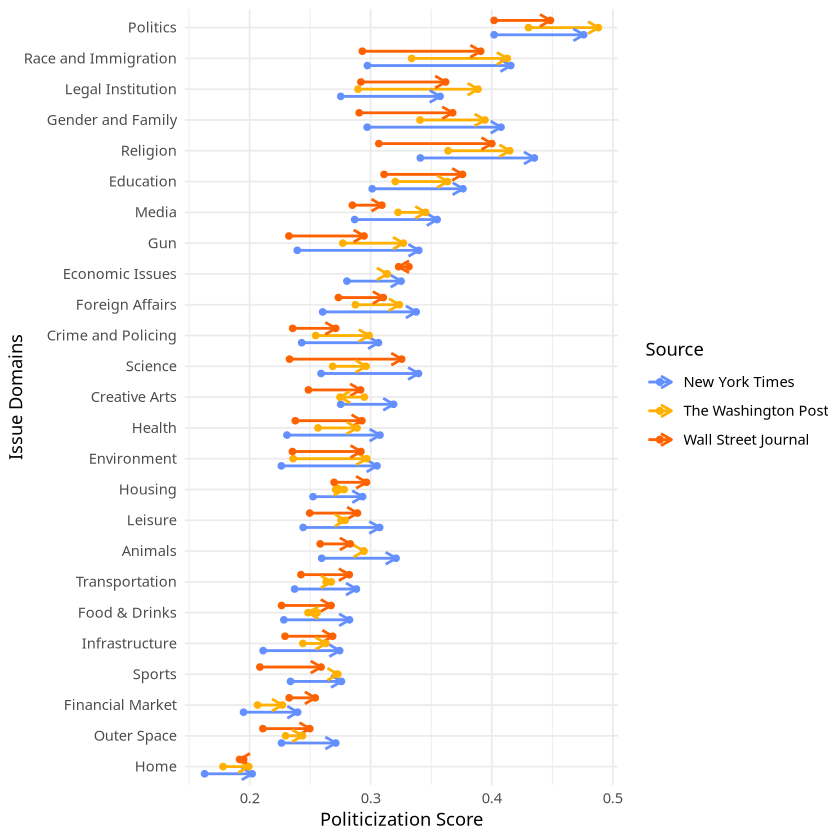

In [18]:
library(ggplot2)

category_year_ideo %>%
  filter(Category != "Other") %>%
  mutate(Category = factor(Category, rev(custom_order))) %>%
  ggplot() +
  geom_segment(
    aes(x = early_value,
        xend = late_value,
        y = Category,
        color = Source),
    position = position_dodge(width = 0.7),
    arrow = arrow(length = unit(0.1, "inches")),
    linewidth = 0.8) +

  geom_point(aes(x = early_value, y = Category, color = Source),
    position = position_dodge(width = 0.7), size = 1.5) +

  geom_point(aes(x = late_value, y = Category, color = Source),
    position = position_dodge(width = 0.7), size = 1.5) +
         
  scale_color_manual(values = c(
    "New York Times" = "#648FFF",
    "The Washington Post" = "#FFB000",
    "Wall Street Journal" = "#FE6100")) + 

  labs(x = "Politicization Score",
       y = "Issue Domains") +
         
  theme_minimal(base_size = 11)

In [19]:
ggsave("newspaper_ideo_cat.png", width = 6.5, height = 7)

`summarise()` has grouped output by 'Category'. You can override using the
`.groups` argument.


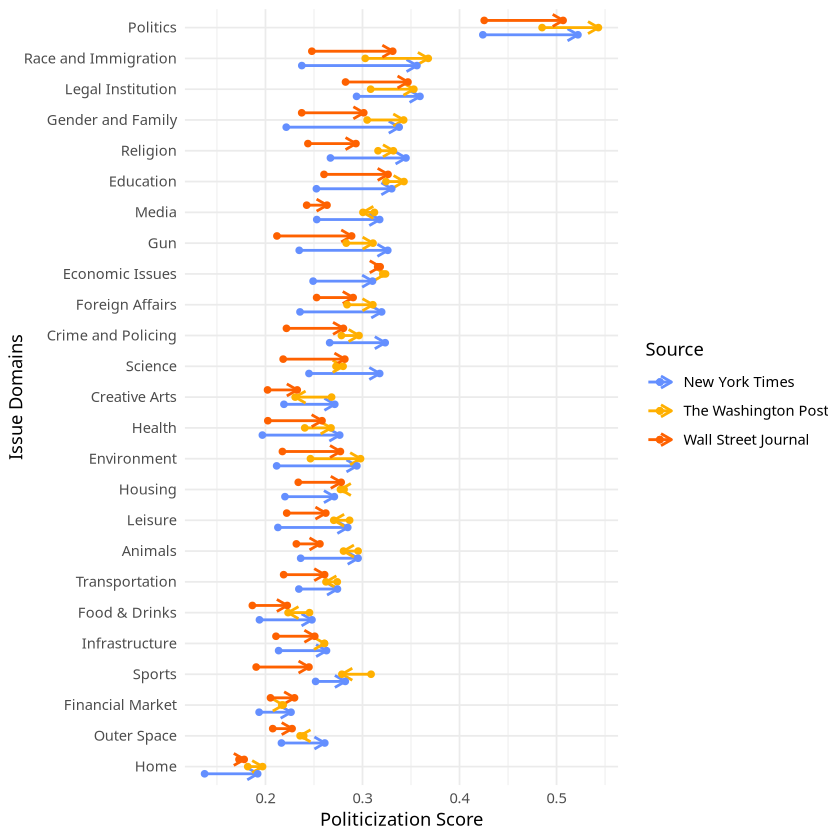

In [20]:
category_year %>%
  group_by(Category, Source) %>%
  summarise(
    late_value  = mean(value_party_avg[year >= 2015 & year <= 2024], na.rm = TRUE),
    early_value = mean(value_party_avg[year >= 1980 & year <= 1989], na.rm = TRUE)
  ) %>%
  ungroup() %>%
  filter(Category != "Other") %>%
  mutate(Category = factor(Category, rev(custom_order))) %>%
  ggplot() +
  geom_segment(
    aes(x = early_value,
        xend = late_value,
        y = Category,
        color = Source),
    position = position_dodge(width = 0.7),
    arrow = arrow(length = unit(0.1, "inches")),
    linewidth = 0.8) +

  geom_point(aes(x = early_value, y = Category, color = Source),
    position = position_dodge(width = 0.7), size = 1.5) +

  geom_point(aes(x = late_value, y = Category, color = Source),
    position = position_dodge(width = 0.7), size = 1.5) +
         
  scale_color_manual(values = c(
    "New York Times" = "#648FFF",
    "The Washington Post" = "#FFB000",
    "Wall Street Journal" = "#FE6100")) + 

  labs(x = "Politicization Score",
       y = "Issue Domains") +
         
  theme_minimal(base_size = 11)

In [22]:
ggsave("newspaper_party_cat.png", width = 6.5, height = 7)